In [15]:
from typing import TypedDict , Dict
from langgraph.graph import StateGraph,START,END

In [16]:
# we now create an agent state, graph schema call whatvever you want
# it is sa shared data structure that keeps track of information as your application runs

class AgentState(TypedDict):  #our state schema
    message: str

def greeting_node(state: AgentState)-> AgentState:
    """simple node that add greeting to the state"""


    state["message"] = "hi " + state["message"] + ", how are you?"

    return state

In [17]:
graph = StateGraph(AgentState)

graph.add_node("greeter",greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()

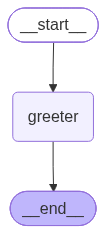

In [18]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
result = app.invoke({"message":"tushar"})

In [20]:
result["message"]

'hi tushar, how are you?'

# exercise 1

**personalised compliment agent**

In [26]:
class graph_schema(TypedDict):
    name: str



def agent(state:graph_schema)->graph_schema:
    state["name"] = state["name"] + ", you are doing an amazing job learning langgraph"

    return state

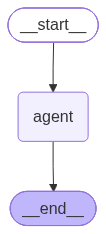

In [27]:
graph = StateGraph(graph_schema)

graph.add_node("agent",agent)
graph.set_entry_point("agent")
graph.set_finish_point("agent")

app1 = graph.compile()

from IPython.display import display,Image
display(Image(app1.get_graph().draw_mermaid_png()))

In [30]:
ans= app1.invoke({"name":"tushar"})
ans["name"]

'tushar, you are doing an amazing job learning langgraph'

# graph 2
## multiple input graph